In [ ]:
# Step 1: Load Dataset
import pandas as pd

chicago_data = pd.DataFrame()
for i in range(1, 20):
    url = f'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_{i}.csv'
    temp_df = pd.read_csv(url)
    chicago_data = pd.concat([chicago_data, temp_df], ignore_index=True)

In [ ]:
# Step 2: Data Cleaning
chicago_data.dropna(subset=['Latitude', 'Longitude', 'DeviceId'], inplace=True)
chicago_data = chicago_data[(chicago_data['Latitude'] != 0) & (chicago_data['Longitude'] != 0)]


In [ ]:
!pip install pygeohash

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans

def cluster_pollution_data(
    df,
    lat_col='Latitude',
    lon_col='Longitude',
    pollution_col='CalibratedPM25',
    method='dbscan',
    eps=0.05,
    min_samples=3,
    k=5,
    return_labels=False
):
    # Validate columns
    for col in [lat_col, lon_col, pollution_col]:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in DataFrame.")

    # Drop rows with missing values
    df_clean = df.dropna(subset=[lat_col, lon_col, pollution_col]).copy()

    # Limit to 5000 rows
    df_clean = df_clean.head(5000)

    # Extract features and scale
    features = df_clean[[lat_col, lon_col, pollution_col]].values
    scaler = StandardScaler()
    scaled = scaler.fit_transform(features)

    # Apply clustering
    if method == 'dbscan':
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(scaled)
    elif method == 'kmeans':
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(scaled)
    else:
        raise ValueError("Method must be 'dbscan' or 'kmeans'")

    df_clean['Cluster'] = labels

    # Filter out noise (DBSCAN)
    clustered = df_clean[df_clean['Cluster'] != -1] if method == 'dbscan' else df_clean

    # Compute centroids
    centroids = clustered.groupby('Cluster')[[lat_col, lon_col]].mean().reset_index(drop=True)

    if return_labels:
        return centroids, df_clean
    return centroids


In [ ]:
subset = chicago_data.dropna(subset=['Latitude', 'Longitude', 'CalibratedPM25']).head(5000)

centroids_db, labeled_db = cluster_pollution_data(
    subset,
    pollution_col='CalibratedPM25',
    method='dbscan',
    eps=0.15,
    return_labels=True
)

# KMeans clustering
centroids_km, labeled_km = cluster_pollution_data(
    subset,
    pollution_col='CalibratedPM25',
    method='kmeans',
    k=6,
    return_labels=True
)


In [ ]:
# Assuming your table is chicago_data with Latitude, Longitude, and Pollution columns

# DBSCAN clustering
centroids_db, labeled_db = cluster_pollution_data(chicago_data, method='dbscan', eps=0.15, return_labels=True)

# KMeans clustering
centroids_km, labeled_km = cluster_pollution_data(chicago_data, method='kmeans', k=6, return_labels=True)


In [ ]:
print(centroids_db.head())
print(labeled_db['Cluster'].value_counts())


    Latitude  Longitude
0  41.795210 -87.625679
1  41.845100 -87.695204
2  41.852365 -87.695271
3  41.852375 -87.695250
Cluster
 0    2165
 2    1712
 1    1103
-1      16
 3       4
Name: count, dtype: int64


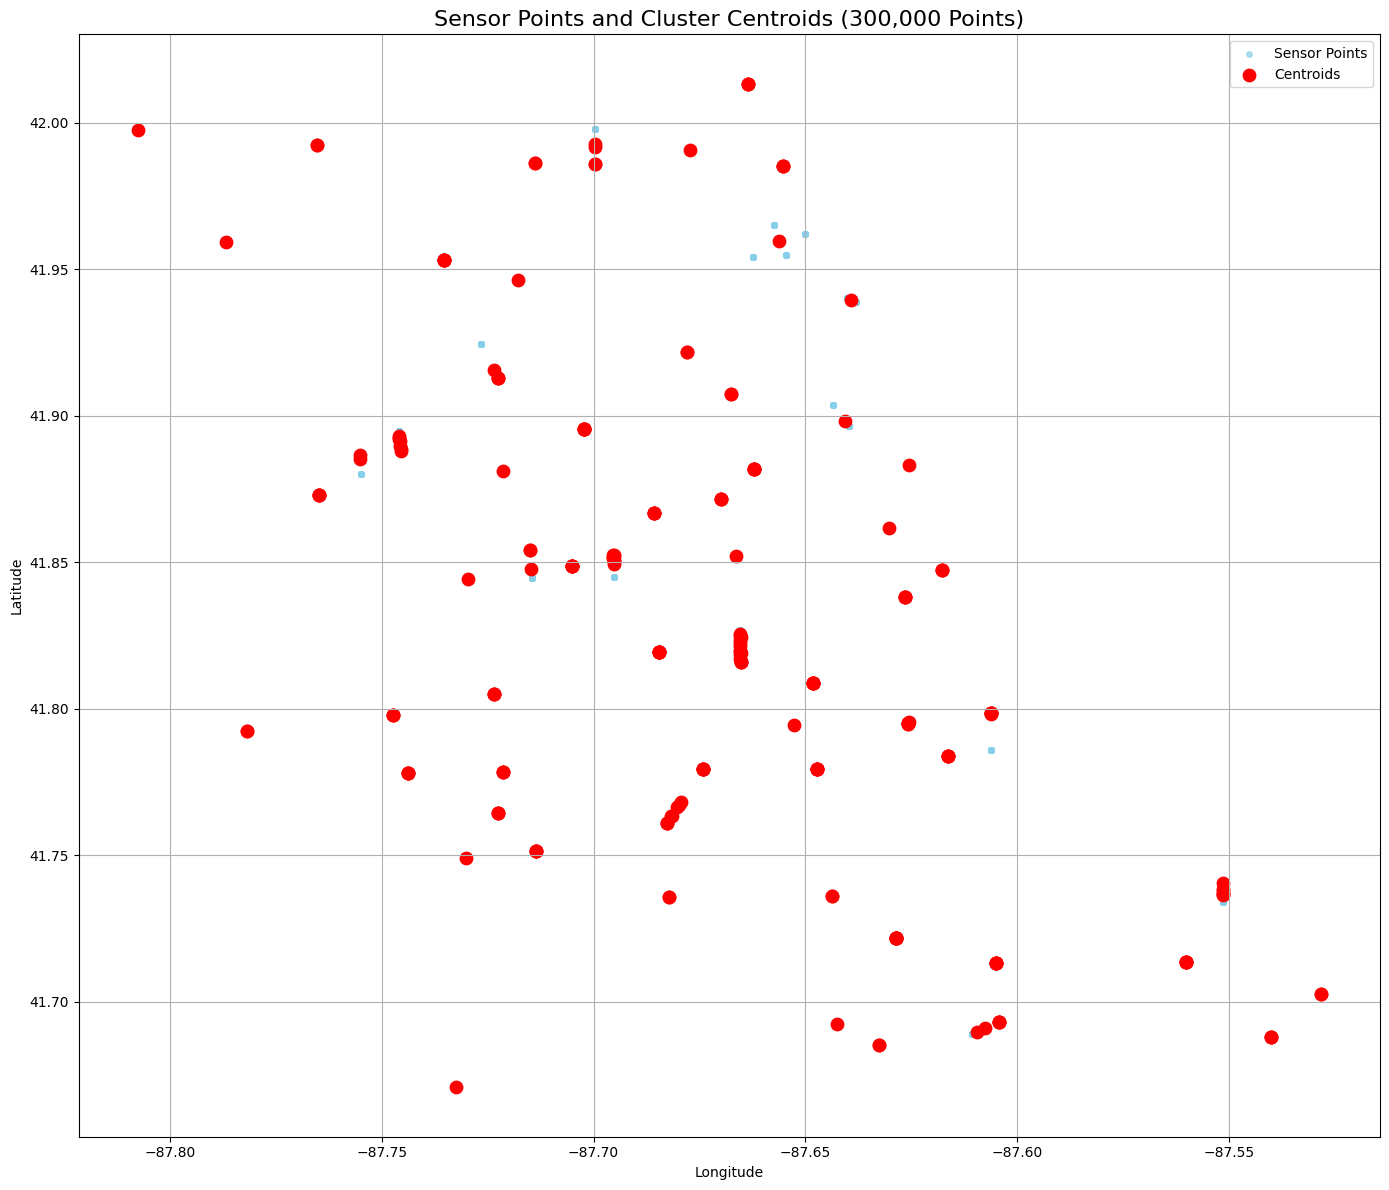

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Step 1: Filter up to 300,000 valid rows
subset = chicago_data.dropna(subset=['Latitude', 'Longitude', 'CalibratedPM25']).head(300000).copy()

# Step 2: Extract features and scale them
features = subset[['Latitude', 'Longitude', 'CalibratedPM25']].values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 3: Apply DBSCAN
db = DBSCAN(eps=0.15, min_samples=3, n_jobs=-1)  # n_jobs=-1 uses all CPU cores
labels = db.fit_predict(scaled_features)
subset['Cluster'] = labels

# Step 4: Remove noise and calculate centroids
clustered = subset[subset['Cluster'] != -1]
centroids = clustered.groupby('Cluster')[['Latitude', 'Longitude']].mean().reset_index()

# Step 5: Plot
# Step 5: Plot with **larger** sensor points
plt.figure(figsize=(14, 12))

plt.scatter(
    clustered['Longitude'],
    clustered['Latitude'],
    c='skyblue',
    s=15,            # ⬅️ Bigger size for sensor points
    alpha=0.7,       # Slight transparency for overlap clarity
    label='Sensor Points'
)

plt.scatter(
    centroids['Longitude'],
    centroids['Latitude'],
    c='red',
    s=80,            # Larger centroids
    marker='o',
    label='Centroids'
)

plt.title("Sensor Points and Cluster Centroids (300,000 Points)", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



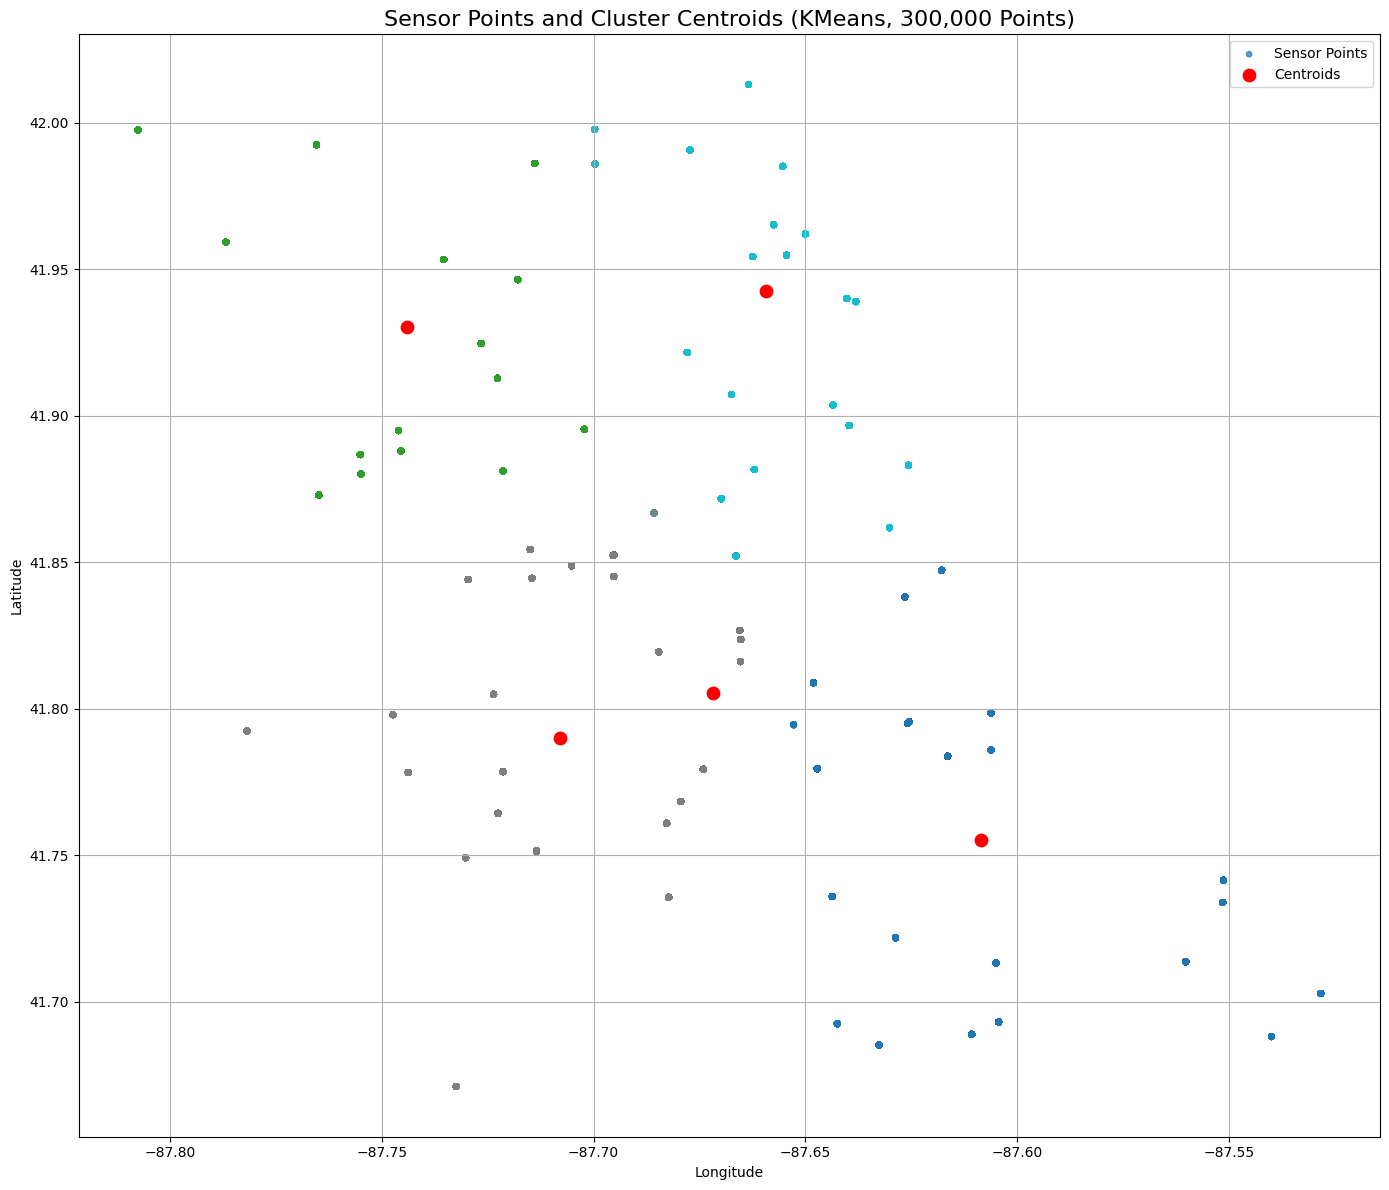

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Filter up to 300,000 valid rows
subset = chicago_data.dropna(subset=['Latitude', 'Longitude', 'CalibratedPM25']).head(300000).copy()

# Step 2: Extract features and scale them
features = subset[['Latitude', 'Longitude', 'CalibratedPM25']].values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 3: Apply KMeans
n_clusters = 5  # You can adjust this number based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(scaled_features)
subset['Cluster'] = labels

# Step 4: Calculate centroids
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=['Latitude', 'Longitude', 'CalibratedPM25'])

# Step 5: Plot
plt.figure(figsize=(14, 12))

plt.scatter(
    subset['Longitude'],
    subset['Latitude'],
    c=subset['Cluster'],
    cmap='tab10',
    s=15,
    alpha=0.7,
    label='Sensor Points'
)

plt.scatter(
    centroids_df['Longitude'],
    centroids_df['Latitude'],
    c='red',
    s=80,
    marker='o',
    label='Centroids'
)

plt.title("Sensor Points and Cluster Centroids (KMeans, 300,000 Points)", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


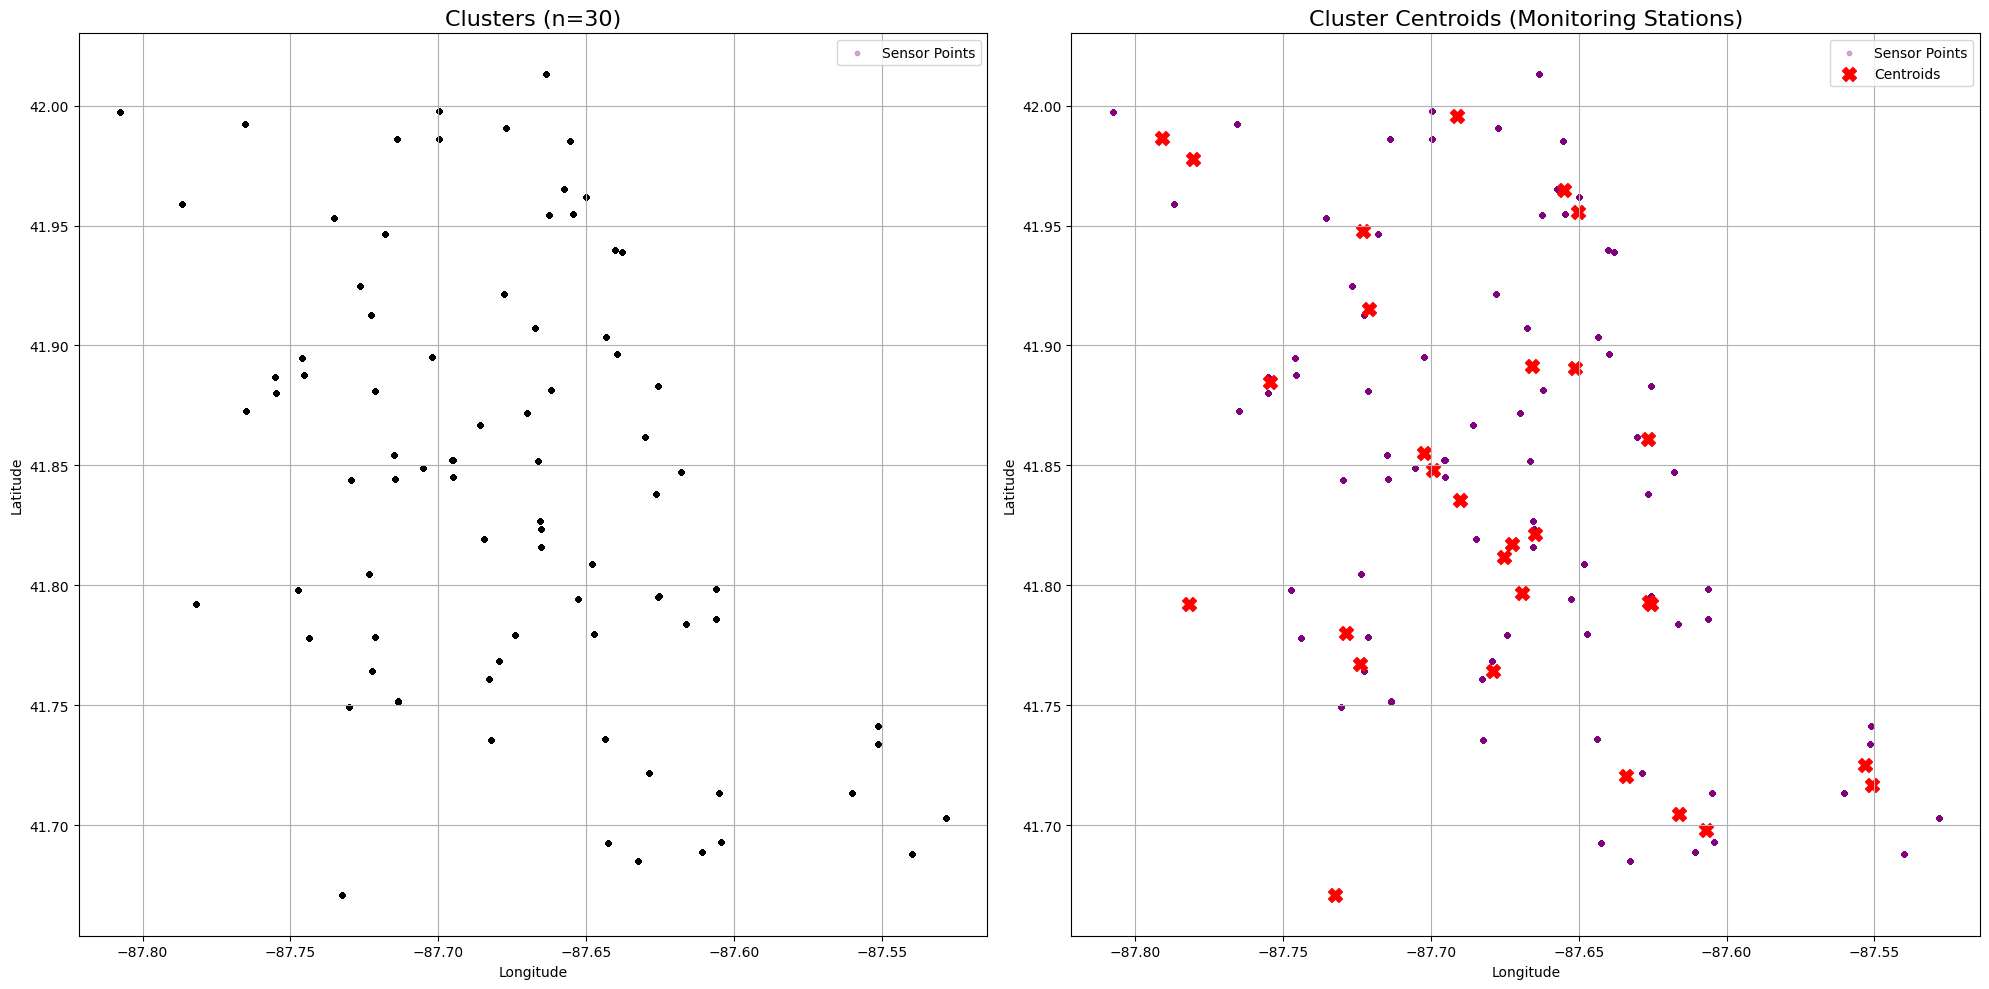

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Filter up to 300,000 valid rows
subset = chicago_data.dropna(subset=['Latitude', 'Longitude', 'CalibratedPM25']).head(300000).copy()

# Step 2: Extract features and scale them
features = subset[['Latitude', 'Longitude', 'CalibratedPM25']].values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 3: Choose fixed number of clusters
n_clusters = 30  # Adjust this as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(scaled_features)
subset['Cluster'] = labels

# Step 4: Calculate centroids
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=['Latitude', 'Longitude', 'CalibratedPM25'])

# Step 5: Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# === Left Plot: Clusters ===
axes[0].scatter(
    subset['Longitude'],
    subset['Latitude'],
    color='purple',
    s=10,
    alpha=0.3,
    label='Sensor Points'
)

for i in range(n_clusters):
    cluster_points = subset[subset['Cluster'] == i]
    axes[0].scatter(
        cluster_points['Longitude'],
        cluster_points['Latitude'],
        color='black',
        s=8,
        alpha=0.6
    )

axes[0].set_title(f"Clusters (n={n_clusters})", fontsize=16)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend()
axes[0].grid(True)

# === Right Plot: Centroids ===
axes[1].scatter(
    subset['Longitude'],
    subset['Latitude'],
    color='purple',
    s=10,
    alpha=0.3,
    label='Sensor Points'
)

axes[1].scatter(
    centroids_df['Longitude'],
    centroids_df['Latitude'],
    color='red',
    s=100,
    marker='X',
    label='Centroids'
)

axes[1].set_title("Cluster Centroids (Monitoring Stations)", fontsize=16)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:

# Step 4: Geohashing
import pygeohash as gh

precision = 6
chicago_data['Geohash'] = chicago_data.apply(lambda x: gh.encode(x['Latitude'], x['Longitude'], precision=precision), axis=1)

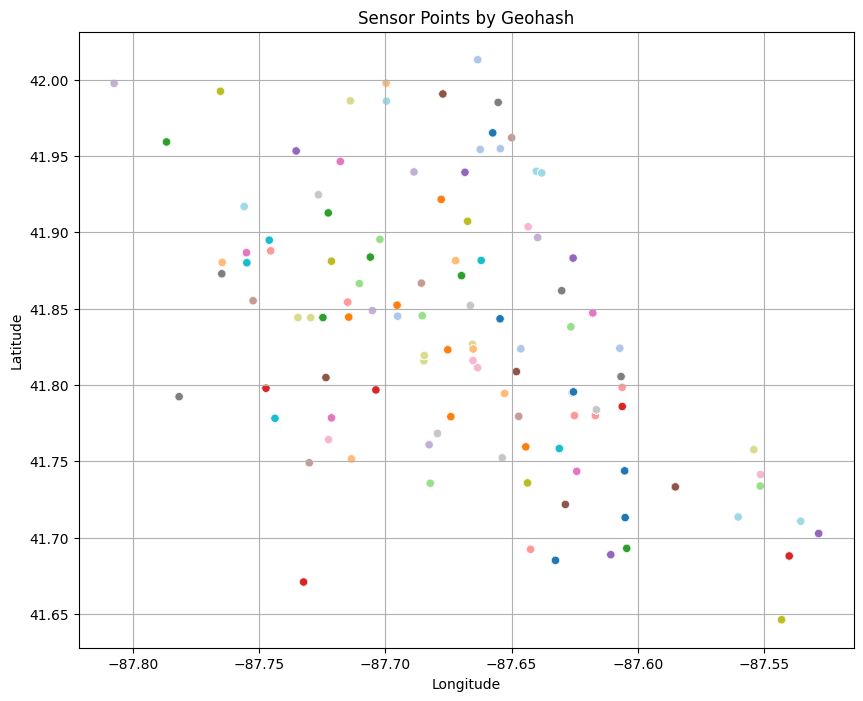

In [ ]:
# 🔵 Graph 1: Geohash Grid Map
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.scatterplot(data=chicago_data, x='Longitude', y='Latitude', hue='Geohash', palette='tab20', legend=False)
plt.title('Sensor Points by Geohash')
plt.grid(True)
plt.show()

In [ ]:
# Step 5: Group by Geohash
geohash_groups = chicago_data.groupby('Geohash')

In [ ]:
# Step 6–9: Clustering Within Each Geohash Group and Calculating Centroids
from sklearn.cluster import KMeans
import numpy as np

centroids = []
cluster_points = []
for name, group in geohash_groups:
    coords = group[['Latitude', 'Longitude']].values
    if len(coords) >= 3:
        kmeans = KMeans(n_clusters=1, random_state=42).fit(coords)
        centroids.append(kmeans.cluster_centers_[0])
        cluster_points.extend(coords)
    elif len(coords) > 0:
        centroids.append(coords[0])
        cluster_points.extend(coords)

In [ ]:
# Step 10: Store All Centroids
centroid_df = pd.DataFrame(centroids, columns=['Latitude', 'Longitude'])

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


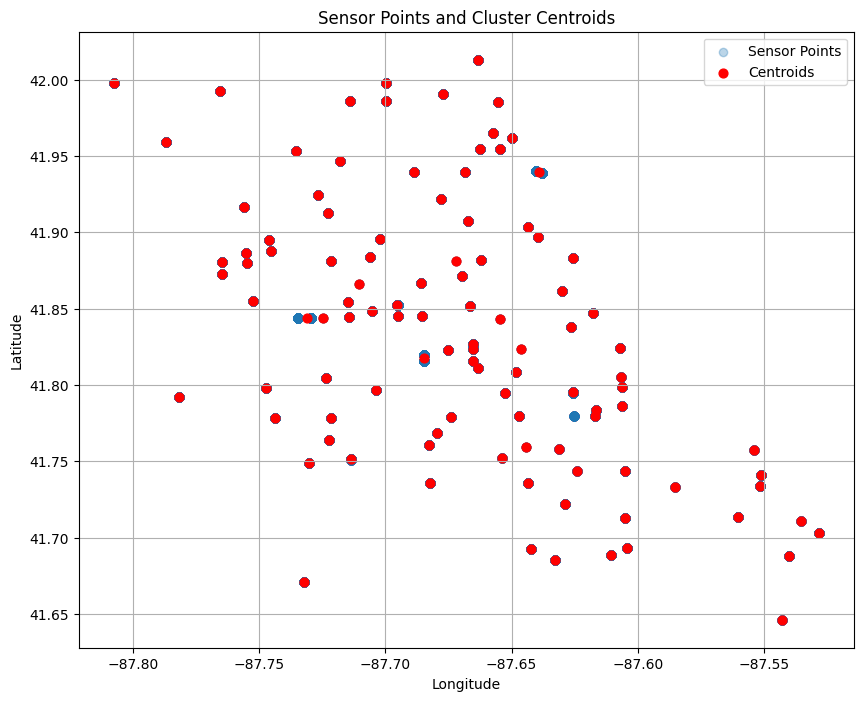

In [ ]:
# 🔵 Graph 2: Cluster Centroids
plt.figure(figsize=(10, 8))
plt.scatter(np.array(cluster_points)[:, 1], np.array(cluster_points)[:, 0], alpha=0.3, label='Sensor Points')
plt.scatter(centroid_df['Longitude'], centroid_df['Latitude'], c='red', label='Centroids', s=40)
plt.title('Sensor Points and Cluster Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 11–12: Build Distance Graph from Centroids
from geopy.distance import geodesic
import networkx as nx

G = nx.Graph()
for i in range(len(centroid_df)):
    G.add_node(i, pos=(centroid_df.iloc[i]['Longitude'], centroid_df.iloc[i]['Latitude']))
    for j in range(i + 1, len(centroid_df)):
        dist = geodesic(
            (centroid_df.iloc[i]['Latitude'], centroid_df.iloc[i]['Longitude']),
            (centroid_df.iloc[j]['Latitude'], centroid_df.iloc[j]['Longitude'])).meters
        G.add_edge(i, j, weight=dist)


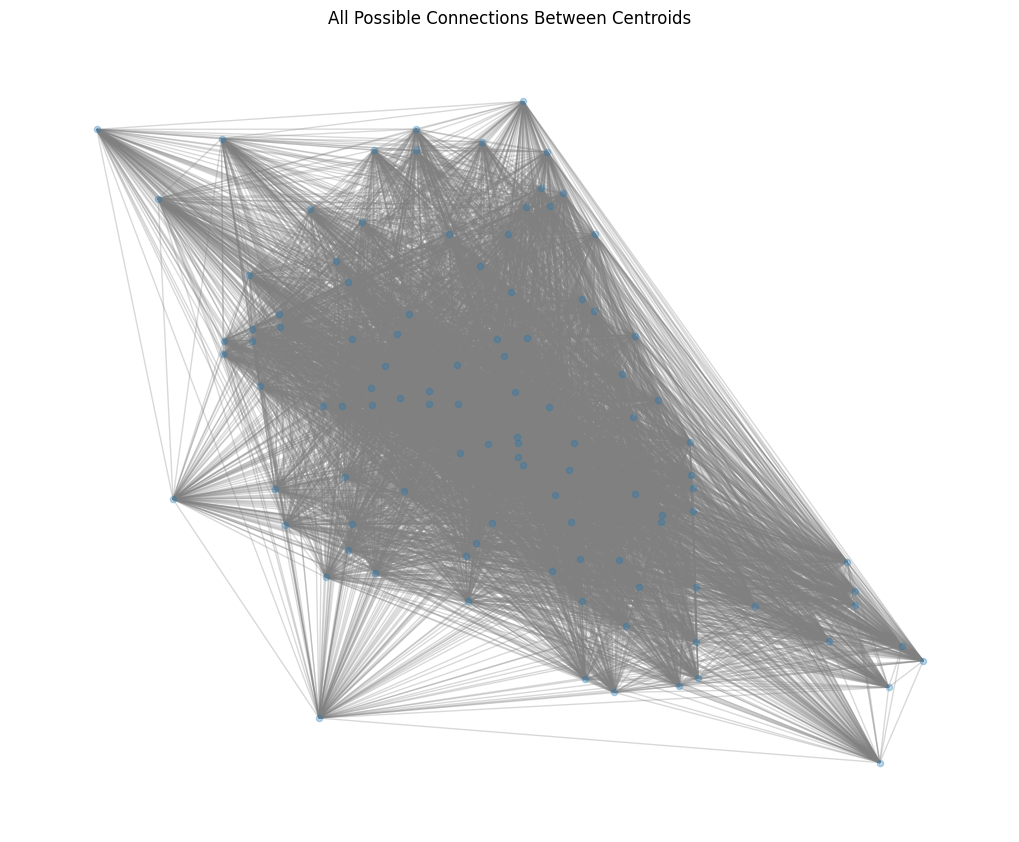

In [ ]:
# 🔵 Graph 3: Full Centroid Graph (Complete Graph)
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_size=20, edge_color='gray', alpha=0.3)
plt.title("All Possible Connections Between Centroids")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [ ]:
# Step 13: Minimum Spanning Tree (MST)
mst = nx.minimum_spanning_tree(G)

In [ ]:
# 🔵 Graph 4: MST Graph
plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_size=20, edge_color='gray', alpha=0.2, label='All Edges')
nx.draw(mst, pos, node_size=40, edge_color='red', label='MST')
plt.title("Minimum Spanning Tree over Sensor Centroids")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Step 14: Extract MST Edges
edges = [(u, v, d['weight']) for u, v, d in mst.edges(data=True)]
mst_edges_df = pd.DataFrame(edges, columns=['From', 'To', 'Distance'])


In [ ]:
# Step 15: Export Results
mst_edges_df.to_csv('mst_all_edges.csv', index=False)

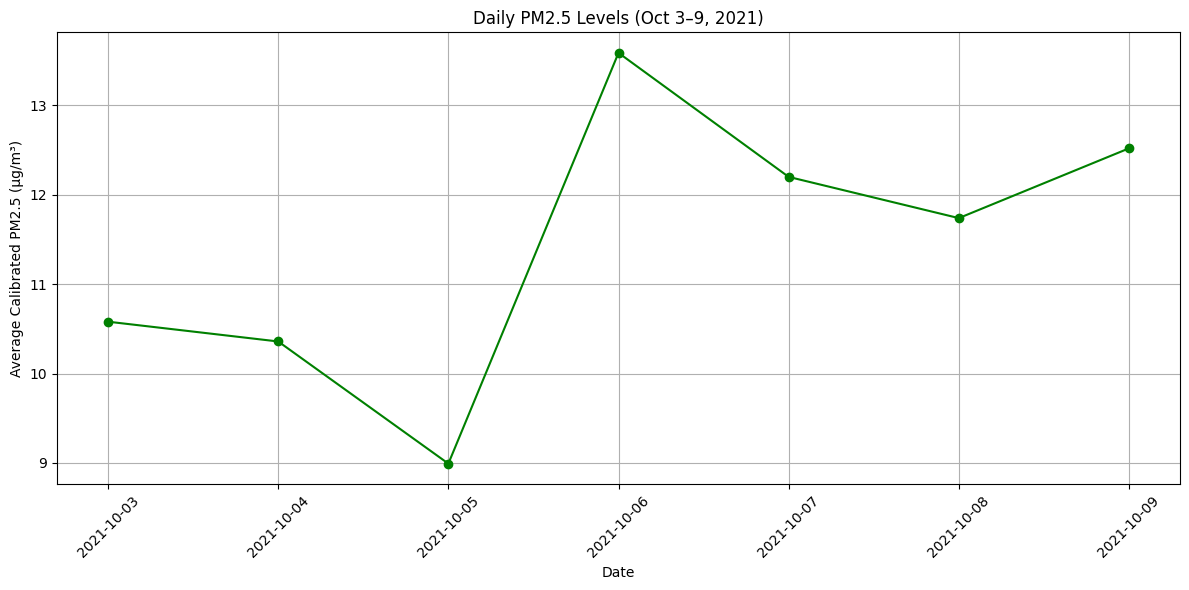

In [ ]:
# Convert to date only (without time)
temp_df['Date'] = temp_df['ReadingDateTimeUTC'].dt.date

# Group by Date and compute average Calibrated PM2.5
daily_avg = temp_df.groupby('Date')['CalibratedPM25'].mean().reset_index()

# Plot the trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_avg['Date'], daily_avg['CalibratedPM25'], marker='o', linestyle='-', color='green')
plt.xlabel('Date')
plt.ylabel('Average Calibrated PM2.5 (µg/m³)')
plt.title('Daily PM2.5 Levels (Oct 3–9, 2021)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



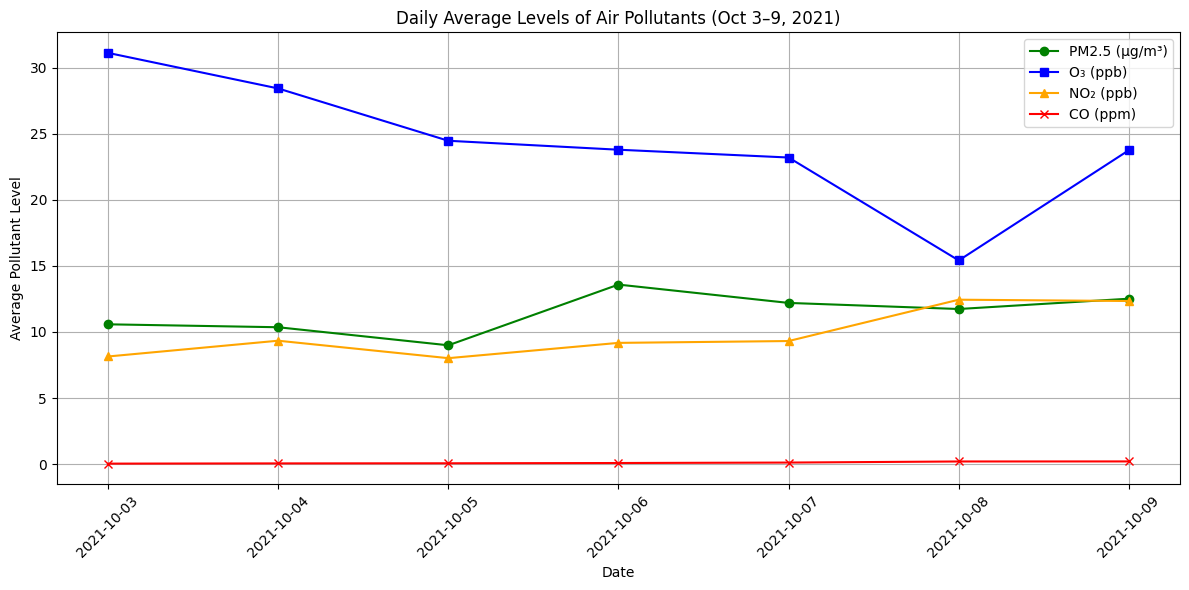

In [ ]:

import matplotlib.pyplot as plt

# Ensure 'Date' column exists
temp_df['Date'] = temp_df['ReadingDateTimeUTC'].dt.date

# Group by Date and calculate daily averages for pollutants
daily_avg = temp_df.groupby('Date')[['CalibratedPM25', 'CalibratedO3', 'CalibratedNO2', 'CO']].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))

plt.plot(daily_avg['Date'], daily_avg['CalibratedPM25'], label='PM2.5 (µg/m³)', color='green', marker='o')
plt.plot(daily_avg['Date'], daily_avg['CalibratedO3'], label='O₃ (ppb)', color='blue', marker='s')
plt.plot(daily_avg['Date'], daily_avg['CalibratedNO2'], label='NO₂ (ppb)', color='orange', marker='^')
plt.plot(daily_avg['Date'], daily_avg['CO'], label='CO (ppm)', color='red', marker='x')

plt.xlabel('Date')
plt.ylabel('Average Pollutant Level')
plt.title('Daily Average Levels of Air Pollutants (Oct 3–9, 2021)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Check the range of dates
print(temp_df['ReadingDateTimeUTC'].min())
print(temp_df['ReadingDateTimeUTC'].max())

# Check unique quarters
print(temp_df['Quarter'].unique())


2021-10-03 00:00:03
2021-10-09 23:59:53
<PeriodArray>
['2021Q4']
Length: 1, dtype: period[Q-DEC]
